In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Raw Data

In [2]:
calendar_df = pd.read_csv("../data/raw/calendar.csv", parse_dates=["date"])
calendar_df["d"] = [f"d_{i}" for i in range(1, len(calendar_df) + 1)]
sales_df = pd.read_csv("../data/raw/sales_train_validation.csv")
wk_prices_df = pd.read_csv("../data/raw/sell_prices.csv")

In [3]:
sku_df = sales_df[(sales_df["store_id"] == "TX_2") & (sales_df["item_id"] == "HOUSEHOLD_1_474")]
sku_df = pd.melt(sku_df,
                 id_vars=["item_id", "dept_id", "cat_id", "store_id", "state_id"],
                 value_vars=[c for c in sku_df.columns if c.startswith("d_")],
                 var_name="d",
                 value_name="demand")

sku_df = sku_df.merge(
    calendar_df,
    on="d",
    how="left",
)
sku_df = sku_df.sort_values("date").reset_index(drop=True)

In [4]:
price_df = wk_prices_df[
    (wk_prices_df["store_id"] == "TX_2") &
    (wk_prices_df["item_id"] == "HOUSEHOLD_1_474")
].copy()

sku_df = sku_df.merge(
    price_df,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

In [5]:
sku_df.head()

,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,weekday,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOUSEHOLD_1_474,HOUSEHOLD_1,HOUSEHOLD,TX_2,TX,d_1,7,2011-01-29,11101,Saturday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0.97
1,HOUSEHOLD_1_474,HOUSEHOLD_1,HOUSEHOLD,TX_2,TX,d_2,2,2011-01-30,11101,Sunday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0.97
2,HOUSEHOLD_1_474,HOUSEHOLD_1,HOUSEHOLD,TX_2,TX,d_3,3,2011-01-31,11101,Monday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0.97
3,HOUSEHOLD_1_474,HOUSEHOLD_1,HOUSEHOLD,TX_2,TX,d_4,3,2011-02-01,11101,Tuesday,...,2,2011,NaN,NaN,NaN,NaN,1,1,0,0.97
4,HOUSEHOLD_1_474,HOUSEHOLD_1,HOUSEHOLD,TX_2,TX,d_5,8,2011-02-02,11101,Wednesday,...,2,2011,NaN,NaN,NaN,NaN,1,0,1,0.97


## Data Exploration

In [6]:
sku_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   item_id       1913 non-null   str           
 1   dept_id       1913 non-null   str           
 2   cat_id        1913 non-null   str           
 3   store_id      1913 non-null   str           
 4   state_id      1913 non-null   str           
 5   d             1913 non-null   str           
 6   demand        1913 non-null   int64         
 7   date          1913 non-null   datetime64[us]
 8   wm_yr_wk      1913 non-null   int64         
 9   weekday       1913 non-null   str           
 10  wday          1913 non-null   int64         
 11  month         1913 non-null   int64         
 12  year          1913 non-null   int64         
 13  event_name_1  154 non-null    str           
 14  event_type_1  154 non-null    str           
 15  event_name_2  4 non-null      str           
 16 

In [7]:
sku_df.describe()

,demand,date,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,sell_price
count,1913.000000,1913,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1.913000e+03
mean,9.871929,2013-09-11 00:00:00,11339.191323,3.997386,6.357554,2013.209096,0.329326,0.329326,0.329326,9.700000e-01
min,0.000000,2011-01-29 00:00:00,11101.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000,9.700000e-01
25%,4.000000,2012-05-21 00:00:00,11217.000000,2.000000,3.000000,2012.000000,0.000000,0.000000,0.000000,9.700000e-01
50%,7.000000,2013-09-11 00:00:00,11333.000000,4.000000,6.000000,2013.000000,0.000000,0.000000,0.000000,9.700000e-01
75%,10.000000,2015-01-02 00:00:00,11448.000000,6.000000,9.000000,2015.000000,1.000000,1.000000,1.000000,9.700000e-01
max,626.000000,2016-04-24 00:00:00,11613.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000,9.700000e-01
std,35.248577,NaN,150.413499,2.001175,3.459678,1.532487,0.470091,0.470091,0.470091,1.110513e-16


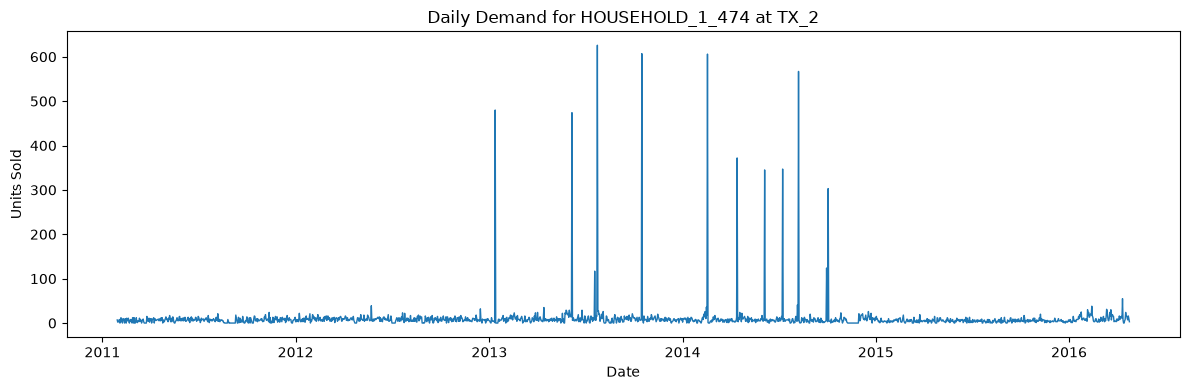

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(sku_df["date"], sku_df["demand"], linewidth=1)
plt.title("Daily Demand for HOUSEHOLD_1_474 at TX_2")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()